# Notebook 4

*In this section, we are using data sacraped from website https://layoffs.fyi/ to get the info for Post-IPO stage companies, and then scrape their stock ticker and founding year from their respective Wikipedia page. After that https://stockanalysis.com/ is used to get the revenue data with the help fo the stock ticker extracted from wikipedia page for the respective company.*

The code below uses data extracted in section1 of the project to get the post_ipo companies list and the dates when the layoffs happened for them. This data is saved in df_post_ipo dataframe

In [1]:
#Extracting company data from parsed_data.json file which conatins data from layoff.fyi website
import json
import pandas as pd

file_path = "parsed_data.json"

with open(file_path, "r") as f:
    data = json.load(f)

post_ipo_data = [
    {
        "Company": entry["Company"],
        "Industry": entry["Industry"],
        "Layoff Date": entry["Date"].split("T")[0]
    }
    for entry in data if entry.get("Stage", "") == "Post-IPO"
]

df_post_ipo = pd.DataFrame(post_ipo_data)
df_post_ipo

,Company,Industry,Layoff Date
0,HP,Hardware,2025-02-28
1,Autodesk,Other,2025-02-27
2,Google,Consumer,2025-02-27
3,eBay,Retail,2025-02-26
4,Dayforce,HR,2025-02-26
...,...,...,...
822,Sezzle,Finance,2022-03-10
823,Adaptive Biotechnologies,Healthcare,2022-03-08
824,Wish,Retail,2022-03-01
825,Peloton,Fitness,2022-02-08


This code below extracts stock_ticker which is the name of the stock company uses in the market and founding year from the Wikipedia pages of the company list we got from df_post_ipo dataframe. The extracted data is stored in df_wiki_data dataframe.

In [10]:
#Searching for the wikipedia page of the respective company
import requests
import re
import pandas as pd
from lxml import html
from urllib.parse import quote

post_ipo_companies = df_post_ipo["Company"].tolist()
WIKI_PAGE_URL = "https://en.wikipedia.org/wiki/{}"
WIKI_SEARCH_API = "https://en.wikipedia.org/w/api.php?action=query&list=search&srsearch={}&format=json"

def find_wikipedia_page(company_name):
    """Try direct Wikipedia URL, if not found, search Wikipedia."""
    search_url = WIKI_PAGE_URL.format(quote(company_name.replace(" ", "_")))
    response = requests.get(search_url)
    if response.status_code == 200:
        return company_name, search_url

    search_response = requests.get(WIKI_SEARCH_API.format(quote(company_name)))
    search_data = search_response.json()

    if "query" in search_data and "search" in search_data["query"] and len(search_data["query"]["search"]) > 0:
        best_match = search_data["query"]["search"][0]["title"]
        return best_match, WIKI_PAGE_URL.format(quote(best_match.replace(" ", "_")))

    return None, None


In [11]:
#Extarcting Founding year and Stock ticker for the company
def extract_wikipedia_info(wiki_url):

    response = requests.get(wiki_url)
    if response.status_code != 200:
        return {"Founding Year": "Not Found", "Traded As": "Not Found", "URL": wiki_url}

    tree = html.fromstring(response.text)
    infobox = tree.xpath('//table[contains(@class, "infobox")]')
    if not infobox:
        return {"Founding Year": "Not Found", "Traded As": "Not Found", "URL": wiki_url}

    infobox_html = html.tostring(infobox[0], encoding="unicode")


    founding_year_match = re.search(r"Founded.*?(\d{4})", infobox_html, re.IGNORECASE)
    founding_year = founding_year_match.group(1) if founding_year_match else "Unknown"
    traded_as = "Not Found"
    traded_as_rows = tree.xpath('//th[contains(., "Traded as")]/following-sibling::td')

    if traded_as_rows:
        raw_traded_as_texts = []

        traded_as_links = traded_as_rows[0].xpath('.//a')
        raw_traded_as_texts.extend([link.text_content().strip() for link in traded_as_links if link.text_content().strip()])

        inline_texts = traded_as_rows[0].xpath('.//text()')
        cleaned_inline_texts = [text.strip() for text in inline_texts if re.search(r"[:A-Z0-9]+", text.strip())]
        raw_traded_as_texts.extend(cleaned_inline_texts)

        raw_traded_as_texts = list(set(raw_traded_as_texts))

        #print(f"\nExtracted 'Traded As' values from {wiki_url}: {raw_traded_as_texts}")

        traded_as = ", ".join(raw_traded_as_texts) if raw_traded_as_texts else "Not Found"

    return {"Founding Year": founding_year, "Traded As": traded_as, "URL": wiki_url}


In [12]:
company_wiki_data = []

for company_name in post_ipo_companies:
    wiki_page, wiki_url = find_wikipedia_page(company_name)

    if wiki_page and wiki_url:
        company_info = extract_wikipedia_info(wiki_url)
        company_info["Company"] = company_name
        company_wiki_data.append(company_info)
    else:
        company_wiki_data.append({"Company": company_name, "Founding Year": "Not Found", "Traded As": "Not Found", "URL": "Not Found"})

df_wiki_data = pd.DataFrame(company_wiki_data)

In [13]:
df_wiki_data = df_wiki_data[df_wiki_data["Founding Year"] != "Not Found"]
df_wiki_data = df_wiki_data[df_wiki_data["Founding Year"] != "Unknown"]
df_wiki_data = df_wiki_data.drop_duplicates(subset=["Company"], keep="first").reset_index(drop=True)

In [14]:
import ast

def convert_to_list(entry):
    if isinstance(entry, list):
        return entry
    if isinstance(entry, str):
        try:
            return ast.literal_eval(entry)
        except (SyntaxError, ValueError):
            return [entry]
    return []


df_wiki_data["Traded As"] = df_wiki_data["Traded As"].apply(convert_to_list)

In [15]:
df_wiki_data["Traded As"] = df_wiki_data["Traded As"].apply(
    lambda x: x[0].split(", ") if isinstance(x, list) and len(x) == 1 and isinstance(x[0], str) else x
)

In [16]:
#Cleaning extracted data from wikipedia infobox for stock ticker and storing it in dataframe
remove_words = {"NASDAQ", "NYSE", "S&P", "LSE", "SEHK", "FWB", "ADR", "Russell",
                "Index", "Component", "MDAX", "Nasdaq-100", "DJIA", "S&P 500", "Nasdaq", "Russell 2000", ":", "components"}

def filter_tickers(traded_list, company_name):
    if not isinstance(traded_list, list):
        return ["Not Found"]

    cleaned_tickers = []

    for item in traded_list:
        item = item.strip()


        if item in remove_words or ".mw-parser" in item:
            continue

        if re.search(r'[^A-Z0-9.-]', item):
            continue


        if any(letter in item for letter in company_name.upper()):
            cleaned_tickers.append(item)

    return cleaned_tickers if cleaned_tickers else ["Not Found"]

df_wiki_data["Traded As"] = df_wiki_data.apply(lambda row: filter_tickers(row["Traded As"], row["Company"]), axis=1)
df_wiki_data


,Founding Year,Traded As,URL,Company
0,1982,[ADSK],https://en.wikipedia.org/wiki/Autodesk,Autodesk
1,1998,[GOOG],https://en.wikipedia.org/wiki/Google,Google
2,1995,[EBAY],https://en.wikipedia.org/wiki/eBay,eBay
3,1992,[DAY],https://en.wikipedia.org/wiki/Dayforce,Dayforce
4,2011,[IBTA],https://en.wikipedia.org/wiki/Ibotta,Ibotta
...,...,...,...,...
276,2016,[BIRD],https://en.wikipedia.org/wiki/Allbirds,Allbirds
277,2000,"[AEX, TKWY]",https://en.wikipedia.org/wiki/Just_Eat_Takeaway,Just Eat Takeaway
278,1894,[Not Found],https://en.wikipedia.org/wiki/Babylon,Babylon
279,2014,[FOOD],https://en.wikipedia.org/wiki/Goodfood,Goodfood


The code below now uses ticker from df_wiki_data to scrape the revenue from stockanalysis.com website. The revenue data extracted is for quarterly basis. The extracted data is saved in df_revenue dataframe.

In [18]:
#Scraper to get revenue data from stockanalysis website
import requests
import time
import random
from lxml import html

tickers = df_wiki_data["Traded As"].dropna().apply(lambda x: x[0] if isinstance(x, list) else x).tolist()

def fetch_revenue_data(ticker):
    url = f"https://stockanalysis.com/stocks/{ticker.lower()}/financials/?p=quarterly"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                      "(KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36"
    }

    #print(f"Accessing: {url}")

    try:
        response = requests.get(url, headers=headers, timeout=10)

        if response.status_code == 429:
            wait_time = random.randint(15, 45)
            #print(f"Rate limited for {ticker}. Retrying after {wait_time} seconds...")
            time.sleep(wait_time)
            return {}

        if response.status_code == 404:
            #print(f"404 Not Found for {ticker}: {url}")
            return {}

        if response.status_code != 200:
            #print(f"Failed to fetch {ticker} (Status: {response.status_code})")
            return {}


        tree = html.fromstring(response.content)


        period_elements = tree.xpath("//th[contains(@id, '-')]/span[@class='hidden sm:inline']/text()")
        periods = [p.strip() for p in period_elements if re.match(r"\w{3} \d{1,2}, \d{4}", p)]


        period_dates = pd.to_datetime(periods, errors="coerce")


        revenue_row = tree.xpath("//tr[td/a[contains(text(), 'Revenue')]]/td[position()>1]/text()")
        revenue_values = [re.sub(r"[^\d.]", "", value) for value in revenue_row if re.search(r"\d", value)]


        revenue_values = [float(value) if value else None for value in revenue_values]


        if len(revenue_values) != len(period_dates):
            #print(f"Mismatch in data length for {ticker}. Periods: {len(period_dates)}, Revenues: {len(revenue_values)}")
            return {}


        if len(period_dates) > 0 and len(revenue_values) > 0:
            revenue_dict = dict(zip(period_dates, revenue_values))
            #print(f"Revenue for {ticker}: {revenue_dict}")
            return revenue_dict
        else:
            #print(f"No revenue data found for {ticker}")
            return {}

    except Exception as e:
        #print(f"Error fetching data for {ticker}: {e}")
        return {}

revenue_data = {}
all_periods = set()

for ticker in tickers:
    #print(f"Fetching data for {ticker}...")
    revenue_dict = fetch_revenue_data(ticker)

    if revenue_dict:
        revenue_data[ticker] = revenue_dict
        all_periods.update(revenue_dict.keys())

    time.sleep(random.randint(3, 7))


all_periods = sorted(list(all_periods))
df_revenue = pd.DataFrame.from_dict(revenue_data, orient="index", columns=all_periods)

df_revenue.index.name = "Ticker"
df_revenue.columns = pd.to_datetime(df_revenue.columns, errors="coerce")
df_revenue = df_revenue.astype(float)
df_revenue = df_revenue.sort_index(axis=1)

In [19]:
df_revenue

,2018-12-31,2019-02-02,2019-03-31,2019-05-04,2019-06-30,2019-08-03,2019-09-30,2019-11-02,2019-12-31,2020-01-31,...,2024-11-03,2024-12-27,2024-12-28,2024-12-29,2024-12-31,2025-01-24,2025-01-25,2025-01-31,2025-02-01,2025-02-02
Ticker,,,,,,,,,,,,,,,,,,,,,
NVTAQ,45.36,NaN,40.55,NaN,53.48,NaN,56.51,NaN,66.29,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KSPN,NaN,127.43,NaN,35.13,NaN,34.26,NaN,28.62,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.56,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TSPH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.71,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BALY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.42,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MBLY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,490.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CART,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,883.00,NaN,NaN,NaN,NaN,NaN
ARM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,983.00,NaN,NaN,NaN,NaN,NaN


The part below is mapping relevant data between the three dataframes we just made.

In [20]:
df_layoffs = df_post_ipo.merge(df_wiki_data[["Company", "Traded As"]],
                               left_on="Company", right_on="Company", how="left")

df_layoffs["Ticker"] = df_layoffs["Traded As"].apply(lambda x: x[0] if isinstance(x, list) else x)
df_layoffs = df_layoffs.drop(columns=["Traded As"])

In [21]:
df_layoffs_revenue = df_layoffs.merge(df_revenue, left_on="Ticker", right_index=True, how="left")

In [22]:
def get_revenue_around_layoff(ticker, layoff_date):

    if ticker not in df_revenue.index:
        return None, None

    revenue_data = df_revenue.loc[ticker]
    layoff_date = pd.to_datetime(layoff_date)
    before = revenue_data[(revenue_data.index <= layoff_date) &
                          (revenue_data.index >= layoff_date - pd.DateOffset(months=9))]

    after = revenue_data[(revenue_data.index > layoff_date) &
                         (revenue_data.index <= layoff_date + pd.DateOffset(months=9))]

    return before.mean(), after.mean()


In [23]:
df_layoffs_revenue["Revenue Before Layoff"], df_layoffs_revenue["Revenue After Layoff"] = zip(
    *df_layoffs_revenue.apply(lambda row: get_revenue_around_layoff(row["Ticker"], row["Layoff Date"]), axis=1)
)
df_layoffs_revenue["Revenue Drop Before Layoff"] = df_layoffs_revenue.apply(
    lambda row: row["Revenue Before Layoff"] > row["Revenue After Layoff"]
    if pd.notnull(row["Revenue Before Layoff"]) and pd.notnull(row["Revenue After Layoff"]) else None, axis=1
)
df_revenue.columns = pd.to_datetime(df_revenue.columns, errors="coerce")

df_revenue.index.name = "Ticker"
df_revenue = df_revenue.apply(pd.to_numeric, errors="coerce")

df_wiki_data["Ticker"] = df_wiki_data["Traded As"].apply(lambda x: x[0] if isinstance(x, list) else x)

company_to_ticker = df_wiki_data.set_index("Company")["Ticker"].to_dict()

df_post_ipo["Ticker"] = df_post_ipo["Company"].map(company_to_ticker)

Code below is to make interactive dashboard to show revenue trend and layoff trend for every company. It is dowloaded in HTML format. You can find it in github or report.

In [24]:
#Plot to show revenue and layoff trend
import plotly.graph_objects as go
import pandas as pd
import plotly.io as pio
from google.colab import files

def generate_filtered_html():

    df_revenue.index = df_revenue.index.str.upper()

    company_to_ticker = df_post_ipo.set_index("Company")["Ticker"].dropna().to_dict()

    valid_companies = {company: ticker for company, ticker in company_to_ticker.items() if ticker in df_revenue.index}

    if not valid_companies:
        print("No valid companies with revenue data found!")
        return
    js_script = """
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <script>
        function updateChart() {
            var selectedCompany = document.getElementById('companyDropdown').value;
            var charts = document.getElementsByClassName('company-chart');
            for (var i = 0; i < charts.length; i++) {
                charts[i].style.display = 'none';
            }
            document.getElementById('chart-' + selectedCompany).style.display = 'block';
        }
    </script>
    """
    dropdown_html = '<select id="companyDropdown" onchange="updateChart()">'
    for company in sorted(valid_companies.keys()):
        dropdown_html += f'<option value="{company}">{company}</option>'
    dropdown_html += '</select>'

    full_html = f"""
    <html>
    <head>
        <title>Revenue Trends with Layoff Markers</title>
        {js_script}
    </head>
    <body>
        <h2>Revenue Trends with Layoff Markers</h2>
        <label for="companyDropdown">Select a Company:</label>
        {dropdown_html}
        <br><br>
    """

    first_company = None
    for company, ticker in valid_companies.items():
        revenue_data = df_revenue.loc[ticker].dropna()
        revenue_data.index = pd.to_datetime(revenue_data.index)

        layoff_dates = df_layoffs_revenue.loc[df_layoffs_revenue["Company"] == company, "Layoff Date"]

        if layoff_dates.empty:
            layoff_dates = []
        else:
            layoff_dates = pd.to_datetime(layoff_dates.dropna()).tolist()

        fig = go.Figure()


        fig.add_trace(go.Scatter(
            x=revenue_data.index,
            y=revenue_data.values,
            mode='lines+markers',
            name=company,
            line=dict(color="blue")
        ))


        for layoff_date in layoff_dates:
            closest_date_idx = revenue_data.index.get_indexer([layoff_date], method="nearest")[0]
            matched_date = revenue_data.index[closest_date_idx]

            fig.add_trace(go.Scatter(
                x=[matched_date],
                y=[revenue_data.loc[matched_date]],
                mode="markers",
                marker=dict(color="red", size=10, symbol="circle"),
                name=f"Layoff ({layoff_date.date()})"
            ))

        fig.update_layout(
            title=f"Revenue Trend for {company}",
            xaxis_title="Date",
            yaxis_title="Revenue ($M)",
            xaxis=dict(tickformat="%Y-%m-%d"),
            height=500
        )

        chart_html = pio.to_html(fig, full_html=False, include_plotlyjs=False)

        if first_company is None:
            first_company = company

        full_html += f"""
        <div id="chart-{company}" class="company-chart" style="display:none;">
            {chart_html}
        </div>
        """
    full_html += f"""
    <script>
        document.getElementById('chart-{first_company}').style.display = 'block';
    </script>
    </body>
    </html>
    """

    html_filename = "filtered_revenue.html"
    with open(html_filename, "w", encoding="utf-8") as f:
        f.write(full_html)


    files.download(html_filename)

    print(f"Saved full interactive dropdown chart as {html_filename}")

generate_filtered_html()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved full interactive dropdown chart as filtered_revenue.html


Analysis for how many companies have revenue drop in quarters before and after layoff time.

In [25]:
#Analysis for Drop before layoff
import pandas as pd

df_wiki_data["Company"] = df_wiki_data["Company"].str.strip()
df_wiki_data["Ticker"] = df_wiki_data["Traded As"].apply(lambda x: x[0] if isinstance(x, list) else x)

df_layoffs = df_post_ipo.merge(df_wiki_data[["Company", "Ticker"]], on="Company", how="left")

df_layoffs["Layoff Date"] = pd.to_datetime(df_layoffs["Layoff Date"], errors='coerce')

def check_revenue_drop(ticker, layoff_date):
    if pd.isna(ticker) or ticker not in df_revenue.index:
        return None

    revenue_data = df_revenue.loc[ticker].dropna()
    revenue_data.index = pd.to_datetime(revenue_data.index, errors='coerce')
    revenue_data = revenue_data.apply(pd.to_numeric, errors='coerce').dropna()

    past_periods = revenue_data.index[(revenue_data.index < layoff_date) &
                                      (revenue_data.index >= layoff_date - pd.DateOffset(months=9))]

    if len(past_periods) < 2:
        return None

    revenue_values = revenue_data.loc[past_periods]
    revenue_change = revenue_values.pct_change().dropna()

    return any(revenue_change < 0)

df_layoffs["Revenue Drop Before Layoff"] = df_layoffs.apply(
    lambda row: check_revenue_drop(row["Ticker_x"], row["Layoff Date"]), axis=1
)

In [26]:
df_layoffs

,Company,Industry,Layoff Date,Ticker_x,Ticker_y,Revenue Drop Before Layoff
0,HP,Hardware,2025-02-28,NaN,NaN,None
1,Autodesk,Other,2025-02-27,ADSK,ADSK,False
2,Google,Consumer,2025-02-27,GOOG,GOOG,False
3,eBay,Retail,2025-02-26,EBAY,EBAY,False
4,Dayforce,HR,2025-02-26,DAY,DAY,False
...,...,...,...,...,...,...
823,Sezzle,Finance,2022-03-10,Not Found,Not Found,None
824,Adaptive Biotechnologies,Healthcare,2022-03-08,NaN,NaN,None
825,Wish,Retail,2022-03-01,NaN,NaN,None
826,Peloton,Fitness,2022-02-08,NaN,NaN,None


In [27]:
company_trend_counts = df_layoffs.groupby("Company")["Revenue Drop Before Layoff"].value_counts().unstack(fill_value=0)
companies_with_revenue_drop = (company_trend_counts[True] > company_trend_counts[False]).sum()
print(f"Number of companies with a revenue drop trend before layoffs: {companies_with_revenue_drop}")


Number of companies with a revenue drop trend before layoffs: 80


In [28]:
#Analysis for drop after layoff
def check_revenue_drop_after(ticker, layoff_date):
    if pd.isna(ticker) or ticker not in df_revenue.index:
        return None

    revenue_data = df_revenue.loc[ticker].dropna()
    revenue_data.index = pd.to_datetime(revenue_data.index, errors='coerce')
    revenue_data = revenue_data.apply(pd.to_numeric, errors='coerce').dropna()
    future_periods = revenue_data.index[(revenue_data.index > layoff_date) &
                                        (revenue_data.index <= layoff_date + pd.DateOffset(months=9))]

    if len(future_periods) < 2:
        return None

    revenue_values = revenue_data.loc[future_periods]
    revenue_change = revenue_values.pct_change().dropna()
    return any(revenue_change < 0)


df_layoffs["Revenue Drop After Layoff"] = df_layoffs.apply(
    lambda row: check_revenue_drop_after(row["Ticker_x"], row["Layoff Date"]), axis=1
)

company_trend_counts_after = df_layoffs.groupby("Company")["Revenue Drop After Layoff"].value_counts().unstack(fill_value=0)

companies_with_revenue_drop_after = (company_trend_counts_after[True] > company_trend_counts_after[False]).sum()
print(f"Number of companies with a revenue drop trend after layoffs: {companies_with_revenue_drop_after}")


Number of companies with a revenue drop trend after layoffs: 61


## Layoffs Trend by Company Age Group

This analysis categorize companies into four age groups: 0-5 years, 6-10 years, 11-20 years, and 21+ years, to examine how layoffs vary with company maturity. To conduct this analysis, company founding years were
extracted from Wikipedia which is in df_wiki_data dataframe, while layoff data was gathered from layoffs.fyi which is in df_post_ipo dataframe

<ipython-input-29-9a91d29f95b8>:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

<ipython-input-29-9a91d29f95b8>:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




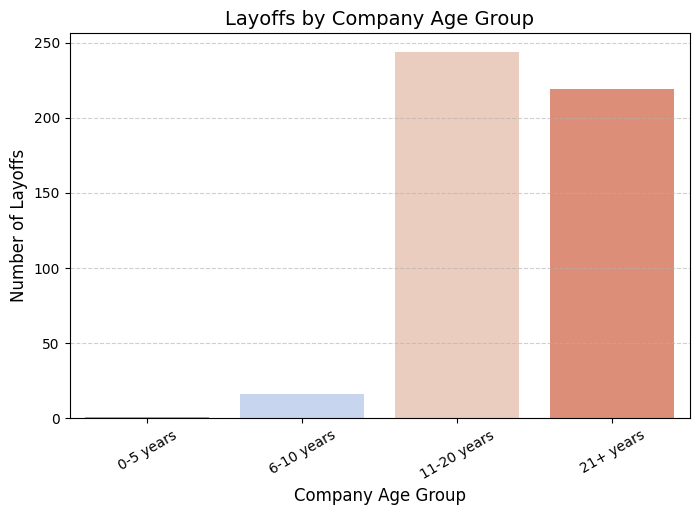

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
df = df_post_ipo.merge(df_wiki_data[['Company', 'Founding Year']], on='Company', how='left')
df['Founding Year'] = pd.to_numeric(df['Founding Year'], errors='coerce')
df['Company Age'] = 2025 - df['Founding Year']

bins = [0, 5, 10, 20, 100]
labels = ['0-5 years', '6-10 years', '11-20 years', '21+ years']
df['Age Group'] = pd.cut(df['Company Age'], bins=bins, labels=labels, right=False)
layoff_counts = df.groupby('Age Group')['Company'].count().reset_index()
layoff_counts.rename(columns={'Company': 'Layoff Count'}, inplace=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=layoff_counts, x='Age Group', y='Layoff Count', palette='coolwarm')


plt.title("Layoffs by Company Age Group", fontsize=14)
plt.xlabel("Company Age Group", fontsize=12)
plt.ylabel("Number of Layoffs", fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.show()

In [30]:
df.to_csv('df_post_ipo', index=False)
files.download('df_post_ipo')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
file_name = "df_wiki_data.csv"


df_wiki_data.to_csv(file_name, index=False)


from google.colab import files
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
file_name = "df_revenue.csv"
df_revenue.to_csv(file_name)
from google.colab import files
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
file_name = "df_layoffs.csv"

df_layoffs.to_csv(file_name)
from google.colab import files
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>